# AI-powered Consumer Trend Signal Detection — Day 1–2 Notebook

**Project idea:** build an AI-powered system that detects early signals of emerging consumer trends from user-generated text data such as product or app reviews.

**Current notebook goal:**
1. Load and inspect the Google Play Store reviews dataset
2. Clean and preprocess review text
3. Build a simple baseline NLP model
4. Evaluate the model
5. Explore text patterns that may later become product/trend signals

**Important note:** this dataset is useful for validating the NLP pipeline. If it does not contain review dates, the time-series part of the project will need a second dataset with timestamps.

## 0. Setup

In [1]:
# If needed, install dependencies in a notebook cell:
# !pip install pandas numpy scikit-learn matplotlib

import os
import re
import string
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)

warnings.filterwarnings("ignore")

pd.set_option("display.max_colwidth", 200)
pd.set_option("display.max_columns", 50)

RANDOM_STATE = 42

## 1. Define scope

In [2]:
PROJECT_SCOPE = """
I will build an AI-powered system that detects early signals of emerging consumer trends
from user-generated text data such as product or app reviews.

This notebook focuses on the first technical milestone:
- inspect and clean review data
- validate that review text contains usable NLP signal
- build a simple baseline model
- explore recurring text patterns that may later support trend detection
"""

print(PROJECT_SCOPE)


I will build an AI-powered system that detects early signals of emerging consumer trends
from user-generated text data such as product or app reviews.

This notebook focuses on the first technical milestone:
- inspect and clean review data
- validate that review text contains usable NLP signal
- build a simple baseline model
- explore recurring text patterns that may later support trend detection



## 2. Load data

In [3]:
# Expected structure:
# project/
# ├── data/
# │   └── googleplaystore_user_reviews.csv
# └── notebooks/
#     └── 01_eda_baseline.ipynb

DATA_PATH = "../data/reviews.csv"

if not os.path.exists(DATA_PATH):
    raise FileNotFoundError(
        f"Could not find file at {DATA_PATH}. "
        "File not found: check DATA_PATH."
    )

df_raw = pd.read_csv(DATA_PATH)

print("Raw dataset shape:", df_raw.shape)
df_raw.head()

Raw dataset shape: (12495, 12)


,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
0,gp:AOqpTOEhZuqSqqWnaKRgv-9ABYdajFUB0WugPGh-SG-fgH355YH_t7J2q4xYo6ZzN3Mc7iSrrTV6ke8hG_fl4Q,Eric Tie,https://play-lh.googleusercontent.com/a-/AOh14GiGET2XHTvsSEsA07ZBPu2s1E6fOXd9WyT_ahChpw,I cannot open the app anymore,1,0,5.4.0.6,2020-10-27 21:24:41,NaN,NaN,newest,com.anydo
1,gp:AOqpTOH0WP4IQKBZ2LrdNmFy_YmpPCVrV3diEU9KGm3fAX6VG0NAZCudCQpQRRI3GLL_tr8DQzUTP1hrOYG74A,john alpha,https://play-lh.googleusercontent.com/a-/AOh14GjpfgjOEbD3brypMeMT3KvhYlWG_nO2bMnMIfY9,I have been begging for a refund from this app for over a month and nobody is replying me,1,0,NaN,2020-10-27 14:03:28,"Please note that from checking our records, your email has been answered, and there was no subscription registered under this address. Please check which email address you are using under you app ...",2020-10-27 15:05:52,newest,com.anydo
2,gp:AOqpTOEMCkJB8Iq1p-r9dPwnSYadA5BkPWTf32Z1azuuTvqA9KWdTQqNNXWZsJEhmSuYUY_LmL-OdUIl4j70wg,Sudhakar .S,https://play-lh.googleusercontent.com/a-/AOh14GidHUHTvHZTXBX36CdxFeccVR2IasC1MHUHXLuFpg,Very costly for the premium version (approx Indian Rupees 910 per year). Better to download the premium version of this app from apkmos website and use it. Microsoft to do list app is far more bet...,1,0,NaN,2020-10-27 08:18:40,NaN,NaN,newest,com.anydo
3,gp:AOqpTOGFrUWuKGycpje8kszj3uwHN6tU_fd4gLVFy9z7hfGM7Gan22TJrN89NmGVEdj5o4U6W4I6slbTx8OsQw,SKGflorida@bellsouth.net DAVID S,https://play-lh.googleusercontent.com/-75aK0WFniac/AAAAAAAAAAI/AAAAAAAAAAA/AMZuucn_nhfTJ2FT63nZ53feI1vVx58DJg/photo.jpg,"Used to keep me organized, but all the 2020 UPDATES have made a mess of things !!! Y cudn't u leave well enuf alone ??? Guess ur techies feel the need to keep making changes to justify continuing ...",1,0,NaN,2020-10-26 13:28:07,"What do you find troublesome about the update? We'd love to get your feedback, by writing to us at https://www.any.do/contact_form. We're constantly trying to provide the best possible app for our...",2020-10-26 14:58:29,newest,com.anydo
4,gp:AOqpTOHls7DW8wmDFzTkHwxuqFkdNQtKHmO6Pt9jhZEQ0Q2rDzcc9WMABIXZNu0pIJOhiFrA4uhMOLq1ZIWKQA,Louann Stoker,https://play-lh.googleusercontent.com/-pBcY_Z-qfB4/AAAAAAAAAAI/AAAAAAAAAAA/AMZuuclb31oz9DIIm_ibRaVH8B2uF2SVZw/photo.jpg,Dan Birthday Oct 28,1,0,5.6.0.7,2020-10-26 06:10:50,NaN,NaN,newest,com.anydo


## 3. Inspect data structure

In [4]:
print("Columns:")
print(df_raw.columns.tolist())

print("\nBasic info:")
df_raw.info()

print("\nMissing values:")
display(df_raw.isna().sum().sort_values(ascending=False))

Columns:
['reviewId', 'userName', 'userImage', 'content', 'score', 'thumbsUpCount', 'reviewCreatedVersion', 'at', 'replyContent', 'repliedAt', 'sortOrder', 'appId']

Basic info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12495 entries, 0 to 12494
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   reviewId              12495 non-null  object
 1   userName              12495 non-null  object
 2   userImage             12495 non-null  object
 3   content               12495 non-null  object
 4   score                 12495 non-null  int64 
 5   thumbsUpCount         12495 non-null  int64 
 6   reviewCreatedVersion  10333 non-null  object
 7   at                    12495 non-null  object
 8   replyContent          5818 non-null   object
 9   repliedAt             5818 non-null   object
 10  sortOrder             12495 non-null  object
 11  appId                 12495 non-null  object
dtypes: int64

replyContent            6677
repliedAt               6677
reviewCreatedVersion    2162
reviewId                   0
userName                   0
userImage                  0
content                    0
score                      0
thumbsUpCount              0
at                         0
sortOrder                  0
appId                      0
dtype: int64

## 4. Quick sample review inspection

In [5]:
# Display a few random rows to understand the data
df_raw.sample(5, random_state=RANDOM_STATE)

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,sortOrder,appId
1766,gp:AOqpTOFFymtN3nnbHJrkAjHfBO5eLncdMIsvSs9EXdjs0XIebapApViAjD2jHzLGME8aAVhIdvI1_m5Z6i57bQ,Rino Rindra,https://play-lh.googleusercontent.com/a-/AOh14GiipZg5edUSKVwIMGxq8N4wzrY8DYcQY_gQnan3tA,It's very easy to add tasks with its incredible Natural Language Processing.,5,0,16.1.1,2020-10-13 00:13:08,NaN,NaN,newest,com.todoist
9813,gp:AOqpTOE4HAQqHMoeH_sGJ850PeeCeB64_AY-eGqyhDx32tRRJE4QEkEPA8W4csLx23gURZzZwR-XXBudqVmfsQ,Neil Power,https://play-lh.googleusercontent.com/a-/AOh14Ghfl_EnZyD_ec4a5ZLaWEtw4nNwxH-FxpFmTldHkA,"Absolutely useless, worked once then never again. Am now living in amonst my household waste like stig of the dump 👍🏻",1,1,2.4.0,2020-05-08 01:24:38,"Neil, this is an issue with your device not Tasks. Huawei add very aggressive power saving to their devices which breaks the standard Android alarm manager function. You will have seen a warning m...",2020-05-08 02:51:12,newest,com.tasks.android
4921,gp:AOqpTOH8mznEDPIiBSAGFgbbG56CX-Bi5otRxNelmUH6-d2xO06NQ92NGRLVweXj00D4thvw6qdUNCJvQ9LFKWE,Fahad Ali Khan,https://play-lh.googleusercontent.com/a-/AOh14Gj8bLm5ii68Yk2d2pBd3xDfPU0TPhi2tr0VWAz1MA,"I bought premium and now I can't login to the app using Facebook. (and I can't login any other way) I get this message: ""Login Failed: You can't use Facebook to log into this app or website becaus...",1,6,1.5.11,2019-11-25 08:43:12,NaN,NaN,newest,com.oristats.habitbull
4959,gp:AOqpTOHXwkKVmlRX4p0THDaK5rTbvlaxHYBindeFA-2qaquhL0Pb_8D1uD4TxAdrWmMHEe_YOFJQnzzu-EUIDz4,Nate Rainey,https://play-lh.googleusercontent.com/a-/AOh14Gg9jmXOLD-wsF08iAJNPKyh5mww1pGcrnL6ssEWdg,"Yo, fix the widget",2,0,1.5.15,2020-09-13 08:43:48,NaN,NaN,newest,com.oristats.habitbull
9798,gp:AOqpTOHi-OnQbla9DvPB9Q5FV5n9oYvduo3b3o67XiWtg6FsqGksDZp5PpNrFoYZmqpnDHBGcGBh5RzYykOuwQ,shivam bhalla,https://play-lh.googleusercontent.com/a-/AOh14GhmHXtsUwiIakzlhPigWz-anTLwMVJA8y24UdgKDQ,Useless app... Niether Reminder nor notifications ping... Wasted too much time on ficing issue.. Even followed developer's instructions..,1,1,2.5.0,2020-06-13 22:57:14,"Shivam, apologies you're having an issue. Unfortunately this is an issue with your device not Tasks. You could have simply sent me an email so I could help you instead of just getting frustrated a...",2020-06-14 14:52:15,newest,com.tasks.android


## 5. Select and rename useful columns

In [6]:

# Dataset columns (google-play-scraper output):
# reviewId, userName, userImage, content, score, thumbsUpCount,
# reviewCreatedVersion, at, replyContent, repliedAt, sortOrder, appId

expected_cols = ["appId", "content", "score", "at"]

missing_cols = [c for c in expected_cols if c not in df_raw.columns]

if missing_cols:
    print("Warning: these expected columns are missing:", missing_cols)
    print("Available columns:", df_raw.columns.tolist())
else:
    df = df_raw[expected_cols].copy()
    df = df.rename(columns={
        "appId": "App",
        "content": "review_text",
        "at": "date"
    })

    # Derive sentiment label from star rating
    def score_to_sentiment(s):
        if s <= 2:
            return "Negative"
        elif s == 3:
            return "Neutral"
        else:
            return "Positive"

    df["sentiment"] = df["score"].apply(score_to_sentiment)

    # Normalise score to polarity range [-1, 1] for compatibility with signal analysis
    df["polarity"] = (df["score"] - 3) / 2

df.head()


,App,review_text,score,date,sentiment,polarity
0,com.anydo,I cannot open the app anymore,1,2020-10-27 21:24:41,Negative,-1.0
1,com.anydo,I have been begging for a refund from this app for over a month and nobody is replying me,1,2020-10-27 14:03:28,Negative,-1.0
2,com.anydo,Very costly for the premium version (approx Indian Rupees 910 per year). Better to download the premium version of this app from apkmos website and use it. Microsoft to do list app is far more bet...,1,2020-10-27 08:18:40,Negative,-1.0
3,com.anydo,"Used to keep me organized, but all the 2020 UPDATES have made a mess of things !!! Y cudn't u leave well enuf alone ??? Guess ur techies feel the need to keep making changes to justify continuing ...",1,2020-10-26 13:28:07,Negative,-1.0
4,com.anydo,Dan Birthday Oct 28,1,2020-10-26 06:10:50,Negative,-1.0


## 6. Drop rows without review text or sentiment label

In [7]:
before = df.shape[0]

df = df.dropna(subset=["review_text", "sentiment"]).copy()

after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after dropping missing review/sentiment: {after}")
print(f"Removed rows: {before - after}")

display(df["sentiment"].value_counts())

Rows before: 12495
Rows after dropping missing review/sentiment: 12495
Removed rows: 0


sentiment
Positive    5654
Negative    4850
Neutral     1991
Name: count, dtype: int64

## 7. EDA: sentiment distribution

sentiment
Positive    5654
Negative    4850
Neutral     1991
Name: count, dtype: int64

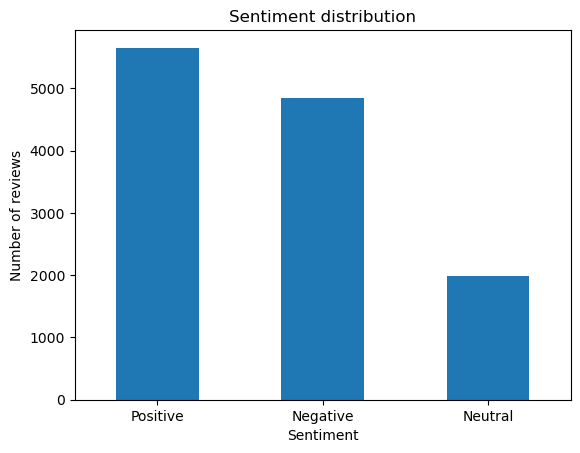

In [8]:
sentiment_counts = df["sentiment"].value_counts()

display(sentiment_counts)

sentiment_counts.plot(kind="bar")
plt.title("Sentiment distribution")
plt.xlabel("Sentiment")
plt.ylabel("Number of reviews")
plt.xticks(rotation=0)
plt.show()

## 8. EDA: review length

,char_count,word_count
count,12495.000000,12495.000000
mean,147.756543,27.675710
std,152.584356,28.381852
min,1.000000,1.000000
25%,37.000000,7.000000
50%,97.000000,18.000000
75%,211.000000,40.000000
max,4076.000000,723.000000


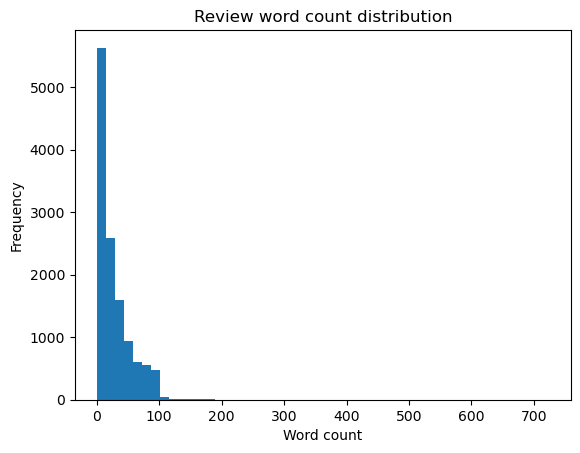

In [9]:
df["char_count"] = df["review_text"].astype(str).apply(len)
df["word_count"] = df["review_text"].astype(str).apply(lambda x: len(x.split()))

display(df[["char_count", "word_count"]].describe())

df["word_count"].plot(kind="hist", bins=50)
plt.title("Review word count distribution")
plt.xlabel("Word count")
plt.ylabel("Frequency")
plt.show()

## 9. Check whether the dataset has a date column

In [10]:

date_like_columns = [
    col for col in df_raw.columns
    if any(token in col.lower() for token in ["date", "time", "timestamp", "reviewed"])
]

# 'at' column (google-play-scraper) contains review timestamp
if "at" in df_raw.columns:
    date_like_columns.append("at")

print("Date-like columns found:", date_like_columns)

if date_like_columns:
    print("Date column available — time-series trend analysis is possible!")
    print("Sample values:", df_raw["at"].dropna().head(5).tolist())
else:
    print(
        "No date-like columns found. This dataset can validate NLP signal extraction, "
        "but a second dataset with timestamps will be needed for real trend-over-time detection."
    )


Date-like columns found: ['at']
Date column available — time-series trend analysis is possible!
Sample values: ['2020-10-27 21:24:41', '2020-10-27 14:03:28', '2020-10-27 08:18:40', '2020-10-26 13:28:07', '2020-10-26 06:10:50']


## 10. Text cleaning

In [11]:
def clean_text(text):
    """
    Basic text cleaning for baseline modeling.
    Keeps the pipeline simple and interpretable.
    """
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)          # remove URLs
    text = re.sub(r"[^a-zA-Z\\s]", " ", text)            # keep letters and spaces
    text = re.sub(r"\\s+", " ", text).strip()            # normalize spaces
    return text

df["clean_text"] = df["review_text"].apply(clean_text)

df[["review_text", "clean_text", "sentiment"]].head(10)

,review_text,clean_text,sentiment
0,I cannot open the app anymore,i cannot open the app anymore,Negative
1,I have been begging for a refund from this app for over a month and nobody is replying me,i have been begging for a refund from this app for over a month and nobody is replying me,Negative
2,Very costly for the premium version (approx Indian Rupees 910 per year). Better to download the premium version of this app from apkmos website and use it. Microsoft to do list app is far more bet...,very costly for the premium version approx indian rupees per year better to download the premium version of this app from apkmos website and use it microsoft to do list app is far more better,Negative
3,"Used to keep me organized, but all the 2020 UPDATES have made a mess of things !!! Y cudn't u leave well enuf alone ??? Guess ur techies feel the need to keep making changes to justify continuing ...",used to keep me organized but all the updates have made a mess of things y cudn t u leave well enuf alone guess ur techies feel the need to keep making changes to justify continuing ...,Negative
4,Dan Birthday Oct 28,dan birthday oct,Negative
5,It has changed how I viewed my different lists. Now they are all jumbled together and I can't find what I need.,it has changed how i viewed my different lists now they are all jumbled together and i can t find what i need,Negative
6,I'm only looking for a grocery list app but every time I tap away from the app I have to tap again (after opening it again) to see the list. I can't find a way to keep a certain list showing when ...,i m only looking for a grocery list app but every time i tap away from the app i have to tap again after opening it again to see the list i can t find a way to keep a certain list showing when ...,Negative
7,"Reset my free trial, new phone I'd like to see if it's better.",reset my free trial new phone i d like to see if it s better,Negative
8,How do to stop monthly payment because i don't use this app anymore,how do to stop monthly payment because i don t use this app anymore,Negative
9,I complain about not crashes and it was immediately fixed!Good job!! Now the crashes have returned! I really need it fixed because I need to change apps otherwise 😩 I followed your instructions on...,i complain about not crashes and it was immediately fixed good job now the crashes have returned i really need it fixed because i need to change apps otherwise i followed your instructions on...,Negative


## 11. Remove empty reviews after cleaning

In [12]:
before = df.shape[0]

df = df[df["clean_text"].str.len() > 0].copy()

after = df.shape[0]

print(f"Rows before: {before}")
print(f"Rows after removing empty clean_text: {after}")
print(f"Removed rows: {before - after}")

Rows before: 12495
Rows after removing empty clean_text: 12395
Removed rows: 100


## 12. Baseline model definition

In [13]:
# Baseline task:
# Predict sentiment from review text.
#
# Why:
# This is not the final project output.
# It is a simple validation step showing whether review text contains usable NLP signal.

X = df["clean_text"]
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=y
)

print("Train size:", X_train.shape[0])
print("Test size:", X_test.shape[0])
print("\nTrain label distribution:")
display(y_train.value_counts(normalize=True))

Train size: 9916
Test size: 2479

Train label distribution:


sentiment
Positive    0.451089
Negative    0.389673
Neutral     0.159238
Name: proportion, dtype: float64

## 13. Train baseline: TF-IDF + Logistic Regression

In [14]:
baseline_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10_000,
        ngram_range=(1, 2),
        min_df=3,
        max_df=0.9,
        stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    ))
])

baseline_model.fit(X_train, y_train)

print("Baseline model trained.")

Baseline model trained.


## 14. Evaluate baseline model

In [15]:
y_pred = baseline_model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
macro_f1 = f1_score(y_test, y_pred, average="macro")

print(f"Accuracy: {accuracy:.4f}")
print(f"Macro F1: {macro_f1:.4f}")

print("\nClassification report:")
print(classification_report(y_test, y_pred))

Accuracy: 0.6720
Macro F1: 0.6038

Classification report:
              precision    recall  f1-score   support

    Negative       0.71      0.71      0.71       966
     Neutral       0.29      0.35      0.32       395
    Positive       0.81      0.75      0.78      1118

    accuracy                           0.67      2479
   macro avg       0.61      0.61      0.60      2479
weighted avg       0.69      0.67      0.68      2479



## 15. Confusion matrix

In [16]:
labels = sorted(y.unique())
cm = confusion_matrix(y_test, y_pred, labels=labels)

cm_df = pd.DataFrame(cm, index=[f"actual_{l}" for l in labels], columns=[f"pred_{l}" for l in labels])
display(cm_df)

,pred_Negative,pred_Neutral,pred_Positive
actual_Negative,688,184,94
actual_Neutral,158,140,97
actual_Positive,120,160,838


## 16. Inspect predictions

In [17]:
results = pd.DataFrame({
    "clean_text": X_test.values,
    "actual": y_test.values,
    "predicted": y_pred
})

print("Sample predictions:")
display(results.sample(10, random_state=RANDOM_STATE))

Sample predictions:


,clean_text,actual,predicted
1755,good job keep up the great work,Positive,Positive
259,i ve used planner pro for years or more now couldn t do without it,Positive,Positive
1917,great app to organise your tasks,Positive,Positive
1001,a few months ago it started to fail to sync with my employer exchange server i used to make it work manually but now it doesn t work even if i sync now,Negative,Negative
56,reminders are not showing notifications for the past week to me sir,Negative,Negative
2421,finished checked tasks reappear after a time as unfinnished,Positive,Negative
2092,it s google calendar with different color scheme,Negative,Neutral
1124,it s amazing ok i was really happy with the ability to create list and then a task and furthermore a subtask with a customizable reminder for each however the problem start there when you turn off...,Positive,Neutral
930,great app so great it is actually the first one and only one so far i bought i love the clear thoroughly customizable interface and the widget on android is super practical i have small ...,Positive,Neutral
2102,please create desktop app,Positive,Negative


In [18]:
print("Correct predictions:")
display(results[results["actual"] == results["predicted"]].sample(5, random_state=RANDOM_STATE))

Correct predictions:


,clean_text,actual,predicted
1388,lost all my lists when i was forced to give email address was good prior to having to start all over,Negative,Negative
1459,paid for the pro version but can t keep the changes i make to the settings,Negative,Negative
614,one of the worst app if someone believes in this app for sure they are going to miss that appointment,Negative,Negative
1079,clicking on the widget doesn t open the app anymore,Negative,Negative
2399,good app but there are some problems which need to be solved,Positive,Positive


In [19]:
print("Incorrect predictions:")
incorrect = results[results["actual"] != results["predicted"]]

if len(incorrect) >= 5:
    display(incorrect.sample(5, random_state=RANDOM_STATE))
else:
    display(incorrect)

Incorrect predictions:


,clean_text,actual,predicted
720,assigning tasks to multiple users is missing which is very much needed wunder list looks much easy to work than this,Negative,Positive
1762,i buyed the pro version but after one day the features of the pro version are disabled and all i get it s this message an error occurred please try again later,Neutral,Negative
664,it worked perfectly for me and benefits me with fantastic pleasures,Positive,Neutral
839,i would give todoist more than five stars however you keep ignoring users for enabling them to show completed tasks by default is just irresponsible please add an option to always show complete...,Negative,Neutral
1628,the concept is quite elligant yet also hard and confusing to understand it would be eaier if there was a calendar setting and or addition to help the user plan along with a timeline,Neutral,Negative


## 17. Explore important words per sentiment class

In [20]:
tfidf = baseline_model.named_steps["tfidf"]
clf = baseline_model.named_steps["clf"]

feature_names = np.array(tfidf.get_feature_names_out())
classes = clf.classes_

for i, class_name in enumerate(classes):
    top_indices = np.argsort(clf.coef_[i])[-20:]
    top_words = feature_names[top_indices]

    print(f"\nTop terms for class: {class_name}")
    print(", ".join(top_words))


Top terms for class: Negative
garbage, don, email, completely, sign, doesn, confusing, terrible, pay, deleted, lost, complicated, crashing, waste, horrible, uninstalling, worst, account, uninstalled, useless

Top terms for class: Neutral
selected, upgrade, gets, confused, calanders, usable, want use, fix, average, unfortunately, widgets, ring, progress, ok, learning, difficult, load, gui, concept, limited

Top terms for class: Positive
tool, helpful, organize, wish, highly, wonderful, awesome, helped, useful, far, perfect, life, fun, excellent, amazing, best, great, easy, helps, love


## 18. Explore potential product/trend signals

In [21]:
# These are starter keywords. Edit them based on what you see in your data.
signal_keywords = [
    "ads",
    "crash",
    "slow",
    "subscription",
    "privacy",
    "login",
    "battery",
    "update",
    "bug",
    "payment",
    "design",
    "feature"
]

signal_summary = []

for keyword in signal_keywords:
    mask = df["clean_text"].str.contains(rf"\b{keyword}\b", na=False)
    subset = df[mask]

    signal_summary.append({
        "keyword": keyword,
        "review_count": len(subset),
        "share_of_reviews": len(subset) / len(df),
        "avg_polarity": subset["polarity"].mean() if "polarity" in subset.columns else np.nan,
        "avg_subjectivity": subset["subjectivity"].mean() if "subjectivity" in subset.columns else np.nan
    })

signal_df = pd.DataFrame(signal_summary).sort_values("review_count", ascending=False)

display(signal_df)

,keyword,review_count,share_of_reviews,avg_polarity,avg_subjectivity
7,update,582,0.046954,-0.271478,NaN
11,feature,464,0.037434,-0.049569,NaN
0,ads,279,0.022509,-0.456989,NaN
3,subscription,210,0.016942,-0.323810,NaN
10,design,121,0.009762,0.053719,NaN
8,bug,119,0.009601,-0.155462,NaN
5,login,88,0.007100,-0.670455,NaN
9,payment,63,0.005083,-0.484127,NaN
2,slow,58,0.004679,-0.189655,NaN
6,battery,52,0.004195,-0.230769,NaN


In [22]:

# Inspect reviews for one keyword.
# Change SELECTED_KEYWORD to explore another signal.

SELECTED_KEYWORD = "ads"

mask = df["clean_text"].str.contains(rf"\b{SELECTED_KEYWORD}\b", na=False)

display_cols = ["App", "review_text", "sentiment", "polarity"]

display(
    df.loc[mask, display_cols]
    .head(20)
)


,App,review_text,sentiment,polarity
80,com.anydo,You need an account because they want to track your cookies for ads,Negative,-1.0
1032,com.todoist,"Money-grubbing app that charges ""premium price"" for features that other apps offer for free. I don't see a single feature that would justify spending 4 bucks a month on it. Ad supported is better ...",Negative,-1.0
1791,com.todoist,"This app has blown me away! Rarely if ever rate an app, but there are no ads, and the free version is still incredibly highly functional... Just so impressed- well done to the team!",Positive,1.0
1939,com.ticktick.task,"Was great till they added fermium garbage limits, and way overpriced premium with crazy overkill features. Got to love the apology to a review. It's amazing how far companies will go to not make a...",Negative,-1.0
1993,com.ticktick.task,"This is a bad app. After purchasing a paid subscription, I got a lot of ads instead of an app that helps me plan my business.I hardly see the task scheduler, just advertising. A lot of advertising...",Negative,-1.0
2026,com.ticktick.task,Bad and have ads,Negative,-1.0
2358,com.ticktick.task,"It's a good app, there are many amazing functions, but there ads are very annoying",Neutral,0.0
2651,com.ticktick.task,"Had some weird hiccups and things to first figure it out, but got it going smoothly. Love the option to share todo lists, and the integration with other calendars. Stand alone web version also goo...",Positive,1.0
2672,com.ticktick.task,"It's got all the features and comforts you could wish for (even in the free version!), looks good, works well, got no ads; it's a no-brainer! Coming from a guy who's tried *all* of the alternative...",Positive,1.0
2797,com.ticktick.task,Have used daily for 2 years now I like how it's customizable and I can see events for several years ahead at a glance. That native alarm is loud enough but not blaring and it's great for repetitiv...,Positive,1.0


## 19. App-level signal exploration

In [23]:

app_summary = (
    df.groupby("App")
    .agg(
        review_count=("clean_text", "count"),
        avg_score=("score", "mean"),
        avg_polarity=("polarity", "mean")
    )
    .sort_values("review_count", ascending=False)
)

display(app_summary.head(20))


,review_count,avg_score,avg_polarity
App,,,
com.appgenix.bizcal,948,2.998945,-0.000527
com.habitrpg.android.habitica,947,3.001056,0.000528
com.gmail.jmartindev.timetune,945,2.994709,-0.002646
com.oristats.habitbull,945,2.995767,-0.002116
com.appxy.planner,944,2.993644,-0.003178
com.anydo,943,2.992577,-0.003712
com.microsoft.todos,942,2.995754,-0.002123
com.todoist,942,2.998938,-0.000531
com.ticktick.task,932,2.989270,-0.005365


## 20. Save cleaned data and baseline outputs

In [24]:
OUTPUT_DIR = "../outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

cleaned_path = os.path.join(OUTPUT_DIR, "cleaned_google_play_reviews.csv")
metrics_path = os.path.join(OUTPUT_DIR, "baseline_metrics.txt")
signals_path = os.path.join(OUTPUT_DIR, "keyword_signal_summary.csv")

df.to_csv(cleaned_path, index=False)
signal_df.to_csv(signals_path, index=False)

with open(metrics_path, "w") as f:
    f.write(f"Accuracy: {accuracy:.4f}\n")
    f.write(f"Macro F1: {macro_f1:.4f}\n")
    f.write("\nClassification report:\n")
    f.write(classification_report(y_test, y_pred))

print("Saved:")
print(cleaned_path)
print(metrics_path)
print(signals_path)

Saved:
../outputs/cleaned_google_play_reviews.csv
../outputs/baseline_metrics.txt
../outputs/keyword_signal_summary.csv


## 21. Notes for project diary

Suggested short report:

**Day 1:** Conducted initial EDA and data cleaning on user-generated app review data to understand dataset structure, quality, and text characteristics. Defined the project scope and prepared a basic preprocessing pipeline for further NLP modeling.

**Day 2:** Built a simple TF-IDF + Logistic Regression baseline to validate whether review text contains useful classification signals. Started exploring recurring review patterns such as ads, crashes, login issues, privacy, and subscriptions as early candidates for product trend signals.

---

## Day 3 — Deep Dive: Error Analysis, App Differences & Sentence Embeddings

## 22. Improved text preprocessing (v2)

Fix regex escaping bugs in the original `clean_text` and add a minimum word-length filter to drop uninformative one- or two-word reviews.

In [25]:
def clean_text_v2(text):
    text = str(text).lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"[^a-z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

df["clean_text_v2"] = df["review_text"].apply(clean_text_v2)

before = len(df)
df = df[df["clean_text_v2"].str.split().str.len() >= 3].copy()

print(f"Rows before min-length filter: {before}")
print(f"Rows after  min-length filter: {len(df)}")
df[["review_text", "clean_text_v2", "sentiment"]].head(5)

Rows before min-length filter: 12395
Rows after  min-length filter: 11190


,review_text,clean_text_v2,sentiment
0,I cannot open the app anymore,i cannot open the app anymore,Negative
1,I have been begging for a refund from this app for over a month and nobody is replying me,i have been begging for a refund from this app for over a month and nobody is replying me,Negative
2,Very costly for the premium version (approx Indian Rupees 910 per year). Better to download the premium version of this app from apkmos website and use it. Microsoft to do list app is far more bet...,very costly for the premium version approx indian rupees per year better to download the premium version of this app from apkmos website and use it microsoft to do list app is far more better,Negative
3,"Used to keep me organized, but all the 2020 UPDATES have made a mess of things !!! Y cudn't u leave well enuf alone ??? Guess ur techies feel the need to keep making changes to justify continuing ...",used to keep me organized but all the updates have made a mess of things y cudn t u leave well enuf alone guess ur techies feel the need to keep making changes to justify continuing to collect the...,Negative
4,Dan Birthday Oct 28,dan birthday oct,Negative


## 23. Retrain baseline on v2 text and compare

In [26]:
X_v2 = df["clean_text_v2"]
y_v2 = df["sentiment"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2, y_v2, test_size=0.2, random_state=RANDOM_STATE, stratify=y_v2
)

model_v2 = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10_000, ngram_range=(1, 2),
        min_df=3, max_df=0.9, stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])
model_v2.fit(X_train_v2, y_train_v2)
y_pred_v2 = model_v2.predict(X_test_v2)

acc_v2 = accuracy_score(y_test_v2, y_pred_v2)
f1_v2  = f1_score(y_test_v2, y_pred_v2, average="macro")

print(f"v1 clean_text  — Accuracy: {accuracy:.4f}  Macro F1: {macro_f1:.4f}")
print(f"v2 clean_text  — Accuracy: {acc_v2:.4f}  Macro F1: {f1_v2:.4f}")
print()
print(classification_report(y_test_v2, y_pred_v2))

v1 clean_text  — Accuracy: 0.6720  Macro F1: 0.6038
v2 clean_text  — Accuracy: 0.6582  Macro F1: 0.5901

              precision    recall  f1-score   support

    Negative       0.72      0.72      0.72       917
     Neutral       0.26      0.32      0.29       368
    Positive       0.80      0.73      0.76       953

    accuracy                           0.66      2238
   macro avg       0.59      0.59      0.59      2238
weighted avg       0.68      0.66      0.67      2238



## 24. Analyze misclassified examples (v2 model)

In [27]:
error_df = pd.DataFrame({
    "review_text": df.loc[X_test_v2.index, "review_text"].values,
    "clean_text":  X_test_v2.values,
    "actual":      y_test_v2.values,
    "predicted":   y_pred_v2
})
error_df = error_df[error_df["actual"] != error_df["predicted"]].copy()
error_df["error_type"] = error_df["actual"] + " → " + error_df["predicted"]

print("Error type breakdown:")
display(error_df["error_type"].value_counts())
print(f"\nTotal errors: {len(error_df)} / {len(y_test_v2)}  ({len(error_df)/len(y_test_v2):.1%})")

Error type breakdown:


error_type
Negative → Neutral     178
Positive → Neutral     156
Neutral → Negative     153
Positive → Negative    102
Neutral → Positive      97
Negative → Positive     79
Name: count, dtype: int64


Total errors: 765 / 2238  (34.2%)


In [28]:
top_error = error_df["error_type"].value_counts().index[0]
n_show = min(8, error_df["error_type"].value_counts().iloc[0])
print(f"Showing {n_show} examples for most common error: {top_error}")
display(
    error_df[error_df["error_type"] == top_error][["review_text", "actual", "predicted"]]
    .sample(n_show, random_state=RANDOM_STATE)
    .reset_index(drop=True)
)

Showing 8 examples for most common error: Negative → Neutral


,review_text,actual,predicted
0,"Doesn't show character customisation, think it needs an update",Negative,Neutral
1,"A shortcut icon within it to be placed for inviting this app to our colleagues, friends to bring under a group. Thereafter he will take up in that particular group.",Negative,Neutral
2,Actually there is a difference between the username and the display name. But thanks for explaining that. Cannot change Display name.,Negative,Neutral
3,It was great until the latest release broke most of the useful functionality,Negative,Neutral
4,"Everytime ask for log in and says log in server issues ,whereas other apps works best offline and no need of log in",Negative,Neutral
5,Cool idea but I never got any of the notifications which is kinda the whole point,Negative,Neutral
6,the widget keep loading and can't use it after I switched of my phone.,Negative,Neutral
7,Like many others I find it too small. Would replace 12 Hours with this if the option to increase the size was added. Edit: Just noticed the last update was 3 years ago so guessing this won't happen,Negative,Neutral


## 25. App-level review differences

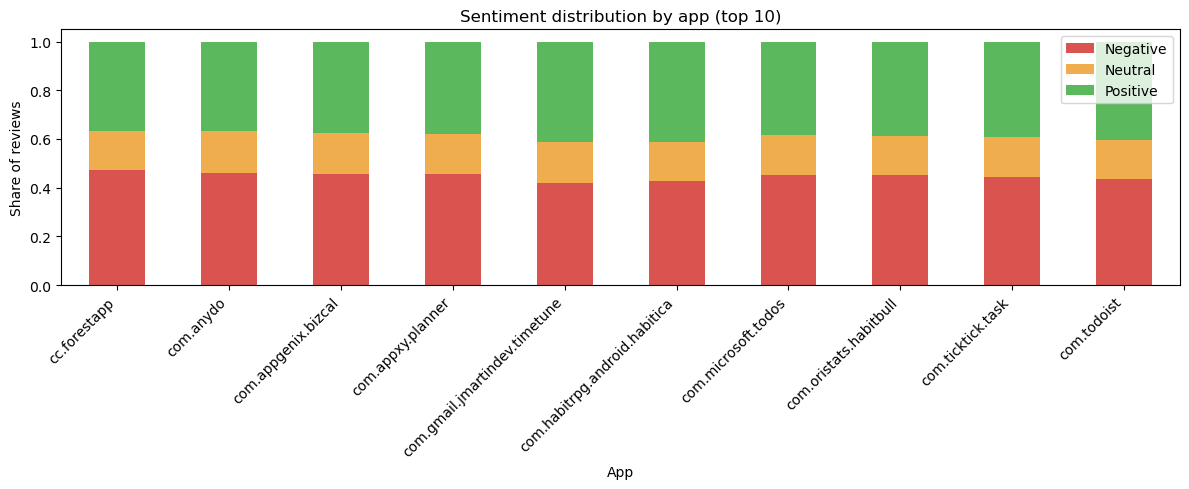

In [29]:
top_apps = df["App"].value_counts().head(10).index.tolist()
df_top = df[df["App"].isin(top_apps)].copy()

app_sentiment = (
    df_top.groupby(["App", "sentiment"]).size().unstack(fill_value=0)
)
app_sentiment_pct = app_sentiment.div(app_sentiment.sum(axis=1), axis=0)

app_sentiment_pct[["Negative", "Neutral", "Positive"]].plot(
    kind="bar", stacked=True, figsize=(12, 5),
    color=["#d9534f", "#f0ad4e", "#5cb85c"]
)
plt.title("Sentiment distribution by app (top 10)")
plt.xlabel("App")
plt.ylabel("Share of reviews")
plt.xticks(rotation=45, ha="right")
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()

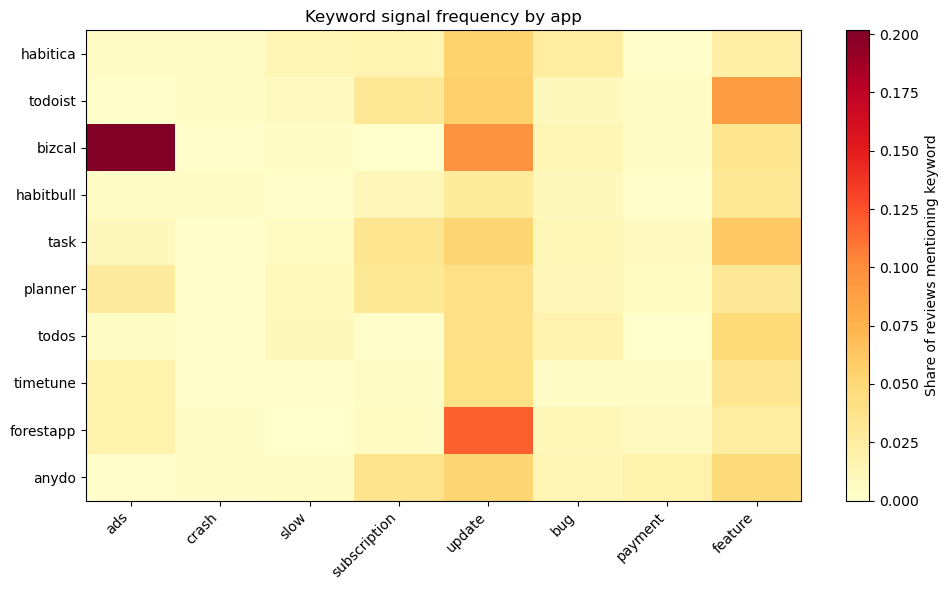

,ads,crash,slow,subscription,update,bug,payment,feature
com.habitrpg.android.habitica,0.004,0.004,0.014,0.015,0.054,0.025,0.001,0.022
com.todoist,0.002,0.003,0.007,0.032,0.055,0.009,0.003,0.090
com.appgenix.bizcal,0.202,0.002,0.005,0.000,0.096,0.013,0.003,0.035
com.oristats.habitbull,0.003,0.005,0.001,0.010,0.028,0.009,0.002,0.031
com.ticktick.task,0.009,0.001,0.006,0.034,0.053,0.012,0.007,0.061
com.appxy.planner,0.027,0.002,0.008,0.030,0.040,0.011,0.006,0.029
com.microsoft.todos,0.004,0.001,0.010,0.001,0.040,0.017,0.000,0.049
com.gmail.jmartindev.timetune,0.018,0.001,0.001,0.002,0.041,0.002,0.002,0.034
cc.forestapp,0.018,0.003,0.000,0.005,0.119,0.011,0.008,0.025
com.anydo,0.001,0.003,0.004,0.036,0.052,0.014,0.019,0.048


In [30]:
signal_kws = ["ads", "crash", "slow", "subscription", "update", "bug", "payment", "feature"]

heatmap_data = {}
for app in top_apps:
    app_df = df_top[df_top["App"] == app]
    heatmap_data[app] = {
        kw: app_df["clean_text_v2"].str.contains(rf"\b{kw}\b", na=False).sum() / len(app_df)
        for kw in signal_kws
    }
heatmap_df = pd.DataFrame(heatmap_data).T

fig, ax = plt.subplots(figsize=(10, 6))
im = ax.imshow(heatmap_df.values, aspect="auto", cmap="YlOrRd")
ax.set_xticks(range(len(signal_kws)))
ax.set_xticklabels(signal_kws, rotation=45, ha="right")
ax.set_yticks(range(len(heatmap_df.index)))
ax.set_yticklabels([a.split(".")[-1] for a in heatmap_df.index])
plt.colorbar(im, ax=ax, label="Share of reviews mentioning keyword")
plt.title("Keyword signal frequency by app")
plt.tight_layout()
plt.show()
display(heatmap_df.round(3))

## 26. Sentence embeddings with all-MiniLM-L6-v2

Switch from sparse TF-IDF to dense semantic vectors using a pre-trained sentence transformer. The model is already available locally.

In [31]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity

MODEL_PATH = (
    "/Users/anna/Downloads/rag-travel-assistant-master/embedding_model/"
    "models--sentence-transformers--all-MiniLM-L6-v2/snapshots/"
    "c9745ed1d9f207416be6d2e6f8de32d1f16199bf"
)

embedder = SentenceTransformer(MODEL_PATH)
print("Model loaded.")
print("Embedding dimension:", embedder.get_sentence_embedding_dimension())

Model loaded.
Embedding dimension: 384


In [32]:
SAMPLE_SIZE = 3000
df_sample = df.sample(SAMPLE_SIZE, random_state=RANDOM_STATE).copy().reset_index(drop=True)

print(f"Encoding {SAMPLE_SIZE} reviews...")
embeddings = embedder.encode(
    df_sample["clean_text_v2"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
print("Embedding matrix shape:", embeddings.shape)

Encoding 3000 reviews...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]

Embedding matrix shape: (3000, 384)


## 27. Compare TF-IDF vs sentence embeddings on classification

In [33]:
y_sample = df_sample["sentiment"]

X_tr_emb, X_te_emb, y_tr, y_te = train_test_split(
    embeddings, y_sample, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sample
)
emb_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
emb_clf.fit(X_tr_emb, y_tr)
y_pred_emb = emb_clf.predict(X_te_emb)
acc_emb = accuracy_score(y_te, y_pred_emb)
f1_emb  = f1_score(y_te, y_pred_emb, average="macro")

X_tfidf_sample = df_sample["clean_text_v2"]
X_tr_tf, X_te_tf, _, _ = train_test_split(
    X_tfidf_sample, y_sample, test_size=0.2, random_state=RANDOM_STATE, stratify=y_sample
)
tfidf_s = Pipeline([
    ("tfidf", TfidfVectorizer(max_features=10_000, ngram_range=(1, 2), min_df=2, max_df=0.9, stop_words="english")),
    ("clf",   LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE))
])
tfidf_s.fit(X_tr_tf, y_tr)
y_pred_tf = tfidf_s.predict(X_te_tf)
acc_tf = accuracy_score(y_te, y_pred_tf)
f1_tf  = f1_score(y_te, y_pred_tf, average="macro")

display(pd.DataFrame({
    "Model":    ["TF-IDF + LR (sample)", "Embeddings + LR (sample)"],
    "Accuracy": [round(acc_tf, 4), round(acc_emb, 4)],
    "Macro F1": [round(f1_tf, 4),  round(f1_emb, 4)]
}))
print("\nEmbeddings — classification report:")
print(classification_report(y_te, y_pred_emb))

,Model,Accuracy,Macro F1
0,TF-IDF + LR (sample),0.6400,0.5655
1,Embeddings + LR (sample),0.6183,0.5656



Embeddings — classification report:
              precision    recall  f1-score   support

    Negative       0.68      0.64      0.66       234
     Neutral       0.24      0.35      0.28       103
    Positive       0.82      0.70      0.76       263

    accuracy                           0.62       600
   macro avg       0.58      0.56      0.57       600
weighted avg       0.66      0.62      0.64       600



## 28. Semantic similarity search

Find the most semantically relevant reviews for any free-text query using cosine similarity over the embedding matrix.

In [34]:
def find_similar(query: str, top_k: int = 5) -> pd.DataFrame:
    q_emb = embedder.encode([query], normalize_embeddings=True)
    sims = cosine_similarity(q_emb, embeddings)[0]
    top_idx = sims.argsort()[::-1][:top_k]
    result = df_sample.iloc[top_idx][["App", "review_text", "sentiment", "score"]].copy()
    result["similarity"] = sims[top_idx].round(3)
    return result.reset_index(drop=True)

In [35]:
test_queries = [
    "app keeps crashing and freezing",
    "too many ads, very annoying",
    "great app, love the design",
    "subscription is too expensive",
]

for q in test_queries:
    print(f"\n--- Query: '{q}' ---")
    display(find_similar(q, top_k=3))


--- Query: 'app keeps crashing and freezing' ---


,App,review_text,sentiment,score,similarity
0,cc.forestapp,App keeps on crashing while starting,Negative,2,0.870
1,com.ticktick.task,I love this app but recently it has been freezing every time i add a new task. It's updated and i even reinstalled it yet it is still happening.,Negative,2,0.752
2,cc.forestapp,"The app keeps on crashing everyday I open it , even after I got a pro account . This feels really irritating . Edit(15-10-2020): The problem was successfully resolved by the team . And apart from ...",Positive,4,0.738



--- Query: 'too many ads, very annoying' ---


,App,review_text,sentiment,score,similarity
0,com.appgenix.bizcal,Too many ads are a deal breaker. Uninstalling.... UNSKIPPABLE ADS ARE A DEAL BREAKER!,Negative,1,0.739
1,com.appgenix.bizcal,Please remove the annoying and intrusive ads!!,Negative,2,0.738
2,com.appgenix.bizcal,Frustrated - Popup ads have become a nuisance. Far too many. I can no longer recommend this app.,Negative,2,0.726



--- Query: 'great app, love the design' ---


,App,review_text,sentiment,score,similarity
0,prox.lab.calclock,Great App. Love the layout,Positive,4,0.858
1,com.artfulagenda.app,great app. love it,Positive,5,0.853
2,com.anydo,"Just awesome, love the app",Positive,5,0.815



--- Query: 'subscription is too expensive' ---


,App,review_text,sentiment,score,similarity
0,com.tasks.android,No subscription tank you. Please full price. I no lack forever.,Negative,2,0.629
1,com.ticktick.task,The majority of things are blocked off by subscription.,Negative,1,0.625
2,com.anydo,Subscription?? How does this application figure that it can be a subscription application? Ridiculous Update after developer response: This is not a subscription application. You are not Netflix o...,Negative,1,0.616


## 29. Notes for project diary — Day 3

**Day 3:**
- Fixed regex preprocessing bugs (`clean_text_v2`) and added a minimum word-length filter.
- Performed error analysis: dominant confusion is **Neutral ↔ Positive/Negative** — expected for borderline 3-star reviews.
- Explored app-level sentiment differences and keyword signal frequency via stacked bar chart and heatmap.
- Introduced **sentence embeddings** (all-MiniLM-L6-v2, loaded locally) as a dense alternative to TF-IDF; compared both on a 3 000-review sample.
- Implemented **cosine-similarity semantic search** — a foundation for RAG-style trend retrieval.

---

# Day 5 — Clustering, Topic Modeling & Time-Series Trend Detection

## 30. K-Means clustering of sentence embeddings

Group reviews by semantic similarity without using labels. Uses the embedding matrix from Section 26 (3 000 reviews). Optimal k is selected using the inertia elbow method.

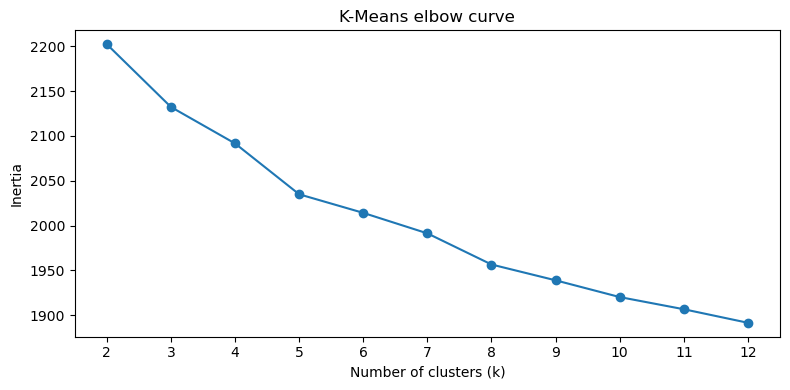

In [36]:
from sklearn.cluster import KMeans

# Elbow: try k from 2 to 12
inertias = []
K_range = range(2, 13)

for k in K_range:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    km.fit(embeddings)
    inertias.append(km.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(list(K_range), inertias, marker="o")
plt.title("K-Means elbow curve")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia")
plt.xticks(list(K_range))
plt.tight_layout()
plt.show()

In [37]:
# Fit final model — choose k based on elbow above
K = 6

km_final = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init="auto")
df_sample["cluster"] = km_final.fit_predict(embeddings)

print("Cluster sizes:")
display(df_sample["cluster"].value_counts().sort_index())

Cluster sizes:


cluster
0    392
1    818
2    332
3    526
4    576
5    356
Name: count, dtype: int64

## 31. Label clusters — top words and example reviews

For each cluster: top TF-IDF words and 3 example reviews. This lets us interpret which consumer theme each cluster represents.

In [38]:
from sklearn.feature_extraction.text import TfidfVectorizer as TF

cluster_tfidf = TF(max_features=5000, stop_words="english", ngram_range=(1, 2))
cluster_tfidf.fit(df_sample["clean_text_v2"])
feature_names = cluster_tfidf.get_feature_names_out()

for cid in sorted(df_sample["cluster"].unique()):
    subset = df_sample[df_sample["cluster"] == cid]
    tmat = cluster_tfidf.transform(subset["clean_text_v2"])
    mean_tfidf = tmat.mean(axis=0).A1
    top_idx = mean_tfidf.argsort()[::-1][:10]
    top_words = ", ".join(feature_names[top_idx])

    sentiment_dist = subset["sentiment"].value_counts(normalize=True).round(2).to_dict()

    print(f"\n{'='*60}")
    print(f"Cluster {cid}  (n={len(subset)})  sentiment: {sentiment_dist}")
    print(f"Top words: {top_words}")
    print("Examples:")
    for ex in subset["review_text"].sample(min(3, len(subset)), random_state=RANDOM_STATE).values:
        print(f"  • {str(ex)[:120]}")


Cluster 0  (n=392)  sentiment: {'Negative': 0.45, 'Positive': 0.37, 'Neutral': 0.18}
Top words: good, like, need, free, bad, version, premium, love, ads, pay
Examples:
  • Having some equipment related bugs
  • Its not free
  • But I want my vip subscription today

Cluster 1  (n=818)  sentiment: {'Positive': 0.57, 'Negative': 0.28, 'Neutral': 0.15}
Top words: app, good, great, love, like, really, good app, great app, use, free
Examples:
  • Really liked this app until they started charging for basic functions on a monthly basis...would have been happy with on
  • Incredibly disappointed with the new update. This app used to be visually pleasing because of the vast variety of trees,
  • I loooove this app but after the update half of the trees were only for premium members , I get you need a way to get mo

Cluster 2  (n=332)  sentiment: {'Negative': 0.44, 'Positive': 0.36, 'Neutral': 0.2}
Top words: calendar, google, app, google calendar, events, like, calendars, sync, calender, event


## 32. LDA topic modeling

LDA (Latent Dirichlet Allocation) is a classic Bayesian method for topic discovery. It works on a count matrix and produces interpretable word lists per topic. Results are compared with the K-Means clusters from Section 30.

In [39]:
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.feature_extraction.text import CountVectorizer

N_TOPICS = 6

count_vec = CountVectorizer(max_features=5000, stop_words="english", min_df=3, ngram_range=(1, 2))
doc_term = count_vec.fit_transform(df_sample["clean_text_v2"])
lda_words = count_vec.get_feature_names_out()

lda = LatentDirichletAllocation(
    n_components=N_TOPICS,
    random_state=RANDOM_STATE,
    max_iter=20,
    learning_method="batch"
)
lda.fit(doc_term)

print(f"LDA perplexity: {lda.perplexity(doc_term):.1f}\n")

for i, topic in enumerate(lda.components_):
    top_words = ", ".join(lda_words[topic.argsort()[::-1][:12]])
    print(f"Topic {i}: {top_words}")

LDA perplexity: 1455.9

Topic 0: app, love, work, love app, doesn, sync, like, really, just, reminder, phone, calendar
Topic 1: version, app, pro, account, premium, pro version, free, trees, free version, phone, really, pay
Topic 2: app, good, use, great, easy, nice, good app, easy use, great app, really, useful, amazing
Topic 3: task, tasks, app, like, list, day, time, add, way, just, daily, set
Topic 4: app, update, best, widget, great, working, works, good, wunderlist, tasks, list, use
Topic 5: app, calendar, don, like, time, google, just, use, using, free, ads, ve


In [40]:
# Assign dominant LDA topic to each review in sample
doc_topics = lda.transform(doc_term)
df_sample["lda_topic"] = doc_topics.argmax(axis=1)

print("LDA topic sizes:")
display(df_sample["lda_topic"].value_counts().sort_index())

# Sentiment breakdown per LDA topic
lda_sentiment = (
    df_sample.groupby(["lda_topic", "sentiment"]).size()
    .unstack(fill_value=0)
)
lda_sentiment_pct = lda_sentiment.div(lda_sentiment.sum(axis=1), axis=0)
display(lda_sentiment_pct[["Negative", "Neutral", "Positive"]].round(2))

LDA topic sizes:


lda_topic
0    453
1    312
2    535
3    631
4    368
5    701
Name: count, dtype: int64

sentiment,Negative,Neutral,Positive
lda_topic,,,
0,0.40,0.19,0.41
1,0.59,0.19,0.22
2,0.16,0.14,0.71
3,0.29,0.19,0.52
4,0.43,0.18,0.39
5,0.54,0.16,0.30


## 33. Time-series: topic/cluster frequency by month

Uses the `date` column from the full `df` dataset. For each month we compute the share of reviews belonging to each LDA topic — this is the trend signal: a growing topic share = an emerging consumer concern.

In [41]:
# Apply LDA to full df (not just sample)
full_doc_term = count_vec.transform(df["clean_text_v2"])
df["lda_topic"] = lda.transform(full_doc_term).argmax(axis=1)

# Parse dates
df["date"] = pd.to_datetime(df["date"], errors="coerce")
df["month"] = df["date"].dt.to_period("M")

topic_by_month = (
    df.groupby(["month", "lda_topic"])
    .size()
    .unstack(fill_value=0)
)
# Normalize to share
topic_by_month_pct = topic_by_month.div(topic_by_month.sum(axis=1), axis=0)

print("Date range:", df["date"].min(), "→", df["date"].max())
display(topic_by_month_pct.tail(6).round(3))

Date range: 2015-02-08 13:58:47 → 2020-10-28 01:44:01


lda_topic,0,1,2,3,4,5
month,,,,,,
2020-05,0.104,0.076,0.136,0.303,0.110,0.271
2020-06,0.142,0.087,0.183,0.235,0.107,0.246
2020-07,0.140,0.069,0.216,0.245,0.106,0.224
2020-08,0.132,0.076,0.229,0.235,0.125,0.202
2020-09,0.140,0.117,0.224,0.213,0.111,0.195
2020-10,0.125,0.117,0.264,0.191,0.111,0.192


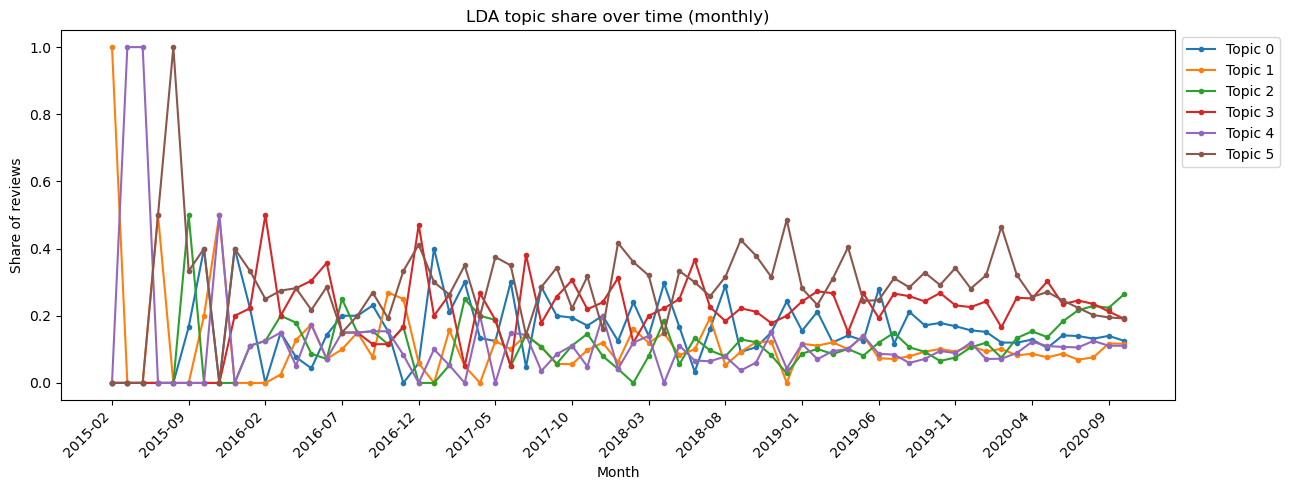

In [42]:
# Plot topic trends over time
fig, ax = plt.subplots(figsize=(13, 5))

for col in topic_by_month_pct.columns:
    ax.plot(
        topic_by_month_pct.index.astype(str),
        topic_by_month_pct[col],
        marker="o", markersize=3, label=f"Topic {col}"
    )

ax.set_title("LDA topic share over time (monthly)")
ax.set_xlabel("Month")
ax.set_ylabel("Share of reviews")
ax.legend(loc="upper left", bbox_to_anchor=(1, 1))
step = max(1, len(topic_by_month_pct) // 12)
ax.set_xticks(range(0, len(topic_by_month_pct), step))
ax.set_xticklabels(topic_by_month_pct.index.astype(str)[::step], rotation=45, ha="right")
plt.tight_layout()
plt.show()

## 34. Detect growing topics

Compare topic share in the first vs last third of the time range — a simple proxy for 'emerging trend'.

In [43]:
n = len(topic_by_month_pct)
first_third = topic_by_month_pct.iloc[:n//3].mean()
last_third  = topic_by_month_pct.iloc[-n//3:].mean()

trend_df = pd.DataFrame({
    "topic": topic_by_month_pct.columns,
    "share_early": first_third.values.round(4),
    "share_recent": last_third.values.round(4),
})
trend_df["delta"] = (trend_df["share_recent"] - trend_df["share_early"]).round(4)
trend_df["direction"] = trend_df["delta"].apply(lambda x: "⬆ GROWING" if x > 0.01 else ("⬇ DECLINING" if x < -0.01 else "→ STABLE"))
trend_df = trend_df.sort_values("delta", ascending=False)

display(trend_df)

,topic,share_early,share_recent,delta,direction
3,3,0.1561,0.2357,0.0796,⬆ GROWING
2,2,0.0959,0.1276,0.0317,⬆ GROWING
0,0,0.1293,0.1560,0.0267,⬆ GROWING
5,5,0.2788,0.2930,0.0142,⬆ GROWING
1,1,0.1593,0.0922,-0.0671,⬇ DECLINING
4,4,0.1806,0.0955,-0.0851,⬇ DECLINING


## 35. Notes for project diary — Day 5

**Day 5:**
- K-Means clustering (k=6) of sentence embeddings: grouped reviews into interpretable consumer themes by top TF-IDF words and examples.
- LDA topic modeling (6 topics) on count vectors: cross-validated thematic structure with cluster results.
- Time-series analysis: tracked LDA topic share month-by-month across the full dataset; identified growing vs declining consumer topics using early/late period comparison.

## 36. Qualitative k selection — top words per cluster at k = 6, 8, 10, 12

For each value of k, print the top-8 TF-IDF words per cluster. Choose the k where cluster themes feel most distinct and interpretable.

In [44]:
from sklearn.cluster import KMeans
from sklearn.feature_extraction.text import TfidfVectorizer as TF

_tfidf = TF(max_features=5000, stop_words="english", ngram_range=(1, 2))
_tfidf.fit(df_sample["clean_text_v2"])
_feat = _tfidf.get_feature_names_out()
_tmat = _tfidf.transform(df_sample["clean_text_v2"])

for k in [6, 8, 10, 12]:
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init="auto")
    labels = km.fit_predict(embeddings)
    print(f"\n{'='*70}")
    print(f"k = {k}")
    print(f"{'='*70}")
    for cid in range(k):
        mask = labels == cid
        mean_tfidf = _tmat[mask].mean(axis=0).A1
        top_words = ", ".join(_feat[mean_tfidf.argsort()[::-1][:8]])
        n = mask.sum()
        print(f"  Cluster {cid:2d} (n={n:4d}): {top_words}")


k = 6
  Cluster  0 (n= 392): good, like, need, free, bad, version, premium, love
  Cluster  1 (n= 818): app, good, great, love, like, really, good app, great app
  Cluster  2 (n= 332): calendar, google, app, google calendar, events, like, calendars, sync
  Cluster  3 (n= 526): tasks, task, reminder, app, reminders, time, list, day
  Cluster  4 (n= 576): app, working, widget, phone, work, update, doesn, sync
  Cluster  5 (n= 356): use, easy, good, easy use, great, useful, simple, works

k = 8
  Cluster  0 (n= 395): tasks, task, list, add, day, like, time, app
  Cluster  1 (n= 285): version, premium, free, app, pay, pro, paid, pro version
  Cluster  2 (n= 591): app, good, great, love, good app, great app, like, really
  Cluster  3 (n= 532): good, use, easy, easy use, great, like, far, love
  Cluster  4 (n= 225): reminder, notification, notifications, reminders, alarm, app, set, time
  Cluster  5 (n= 317): calendar, google, app, google calendar, events, like, calendars, sync
  Cluster  6

---

# Day 6 — Final Clustering (k=12), Cluster Naming & Trend Scoring

## 37. Final K-Means model with k=12

Based on the qualitative evaluation in Section 36, k=12 gives the most granular and interpretable themes. Notably, it separates 'ads' into its own cluster (n=71) — a clear actionable signal.

In [45]:
# Fit final k=12 model on the full embedding sample
km12 = KMeans(n_clusters=12, random_state=RANDOM_STATE, n_init="auto")
df_sample["cluster12"] = km12.fit_predict(embeddings)

print("Cluster sizes (k=12):")
display(df_sample["cluster12"].value_counts().sort_index())

Cluster sizes (k=12):


cluster12
0     231
1     208
2     251
3     424
4     223
5     210
6      71
7     298
8     414
9     277
10    294
11     99
Name: count, dtype: int64

## 38. Name each cluster

Assign a short business-readable label to each cluster based on its top TF-IDF words and example reviews. These labels will be used in all downstream analysis.

In [46]:
from sklearn.feature_extraction.text import TfidfVectorizer as TF

_tv = TF(max_features=5000, stop_words="english", ngram_range=(1, 2))
_tv.fit(df_sample["clean_text_v2"])
_feat = _tv.get_feature_names_out()
_tmat = _tv.transform(df_sample["clean_text_v2"])

# Print top words per cluster so you can verify the labels below
for cid in range(12):
    mask = (df_sample["cluster12"] == cid).values
    mean_tfidf = _tmat[mask].mean(axis=0).A1
    top_words = ", ".join(_feat[mean_tfidf.argsort()[::-1][:10]])
    n = mask.sum()
    print(f"Cluster {cid:2d} (n={n:4d}): {top_words}")

Cluster  0 (n= 231): tasks, task, list, lists, completed, add, wunderlist, just, option, like
Cluster  1 (n= 208): premium, free, version, pay, pro, paid, app, features, pro version, subscription
Cluster  2 (n= 251): app, good, good app, great, love, great app, nice, love app, nice app, really
Cluster  3 (n= 424): good, use, easy, easy use, far, simple, like, love, need, great
Cluster  4 (n= 223): reminder, notification, notifications, reminders, alarm, app, set, sound, time, remind
Cluster  5 (n= 210): habit, habits, day, track, helps, great, tasks, helpful, time, way
Cluster  6 (n=  71): ads, app, calendar, ad, intrusive, annoying, screen, years, pop, version
Cluster  7 (n= 298): app, version, trees, phone, update, good, like, really, work, love
Cluster  8 (n= 414): app, tasks, great, like, time, good, task, really, best, love
Cluster  9 (n= 277): sync, work, working, doesn, app, account, sign, phone, login, fix
Cluster 10 (n= 294): calendar, google, google calendar, app, events, lik

In [47]:
# Business labels assigned based on top words and examples from Section 36
CLUSTER_LABELS = {
    0:  "Task management",
    1:  "Premium / paywall friction",
    2:  "General positive",
    3:  "Ease of use",
    4:  "Reminders & notifications",
    5:  "Habit tracking",
    6:  "Ads friction",
    7:  "App stability & updates",
    8:  "General task/app praise",
    9:  "Sync & login issues",
    10: "Calendar integration",
    11: "Widget issues",
}

df_sample["cluster_label"] = df_sample["cluster12"].map(CLUSTER_LABELS)

# Propagate k=12 labels to full df using nearest-centroid assignment
full_embeddings_all = embedder.encode(
    df["clean_text_v2"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)
df["cluster12"] = km12.predict(full_embeddings_all)
df["cluster_label"] = df["cluster12"].map(CLUSTER_LABELS)

print("Full dataset cluster distribution:")
display(df["cluster_label"].value_counts())

Batches:   0%|          | 0/175 [00:00<?, ?it/s]

Full dataset cluster distribution:


cluster_label
Ease of use                   1613
General task/app praise       1467
App stability & updates       1153
Sync & login issues           1051
Calendar integration          1029
General positive               911
Reminders & notifications      895
Task management                832
Premium / paywall friction     822
Habit tracking                 768
Widget issues                  386
Ads friction                   263
Name: count, dtype: int64

## 39. Time-series per cluster (k=12)

Track the monthly share of each cluster across the full dataset. This turns cluster membership into a trend signal — a rising cluster share means that consumer theme is growing.

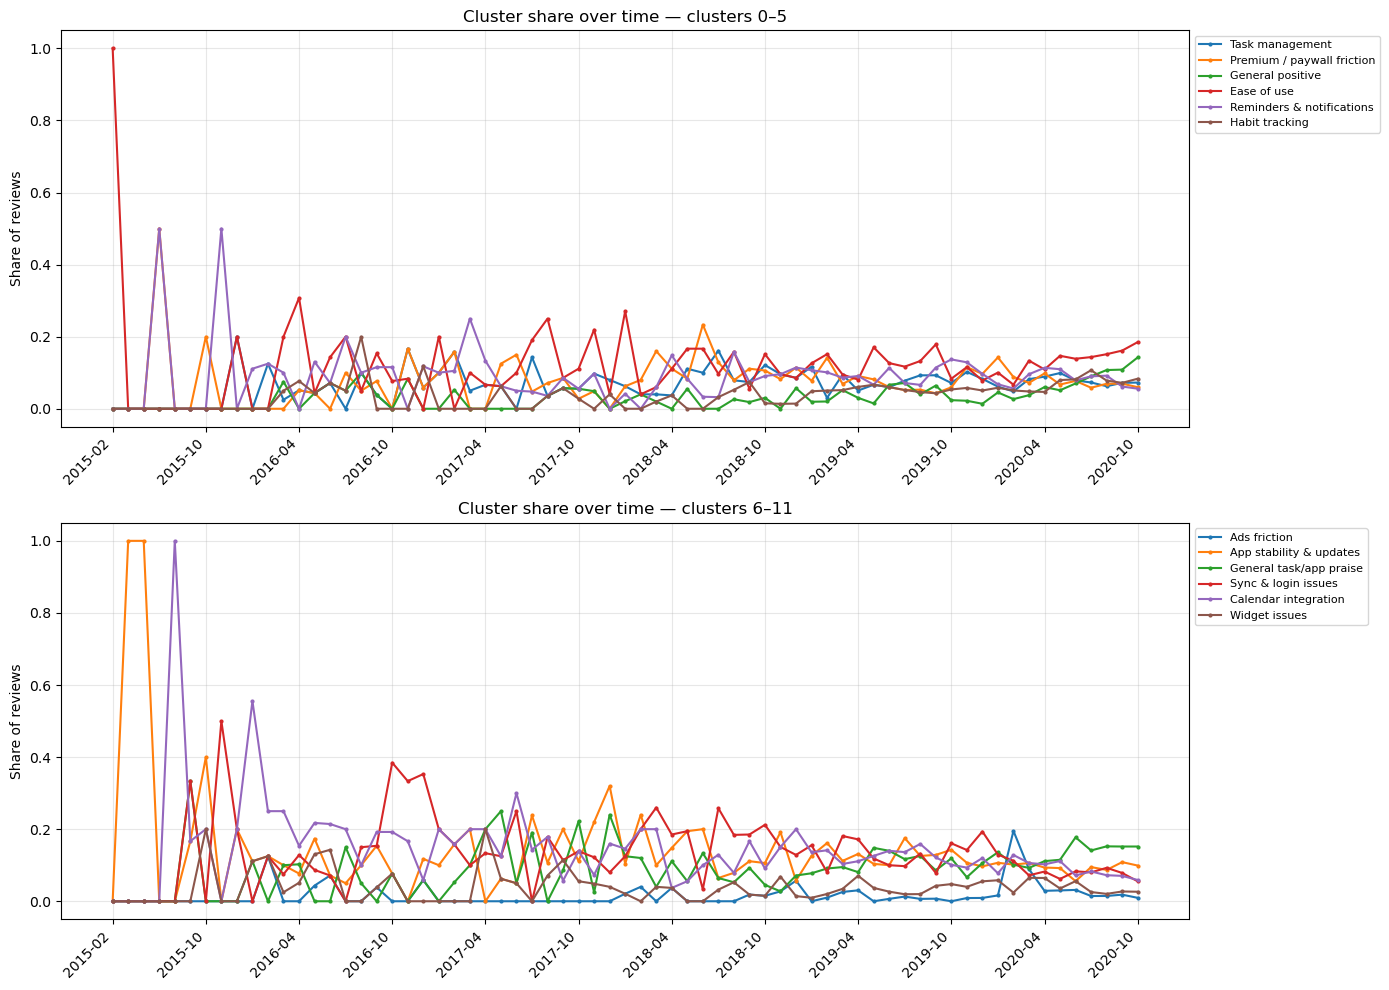

In [48]:
cluster_by_month = (
    df.groupby(["month", "cluster_label"])
    .size()
    .unstack(fill_value=0)
)
cluster_by_month_pct = cluster_by_month.div(cluster_by_month.sum(axis=1), axis=0)

# Plot — split into two charts for readability
labels_sorted = list(CLUSTER_LABELS.values())
half = len(labels_sorted) // 2

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
for ax, cols in zip(axes, [labels_sorted[:half], labels_sorted[half:]]):
    cols_present = [c for c in cols if c in cluster_by_month_pct.columns]
    for col in cols_present:
        ax.plot(
            cluster_by_month_pct.index.astype(str),
            cluster_by_month_pct[col],
            marker="o", markersize=2, label=col
        )
    step = max(1, len(cluster_by_month_pct) // 10)
    ax.set_xticks(range(0, len(cluster_by_month_pct), step))
    ax.set_xticklabels(cluster_by_month_pct.index.astype(str)[::step], rotation=45, ha="right")
    ax.set_ylabel("Share of reviews")
    ax.legend(loc="upper left", bbox_to_anchor=(1, 1), fontsize=8)
    ax.grid(alpha=0.3)

axes[0].set_title("Cluster share over time — clusters 0–5")
axes[1].set_title("Cluster share over time — clusters 6–11")
plt.tight_layout()
plt.show()

## 40. Trend score: rank clusters by growth rate × negativity

A cluster is a high-priority signal if it is **growing** AND **negative** (= unmet consumer need). Trend score = growth_rate × negative_share.

In [49]:
n_months = len(cluster_by_month_pct)
early = cluster_by_month_pct.iloc[:n_months//3].mean()
recent = cluster_by_month_pct.iloc[-n_months//3:].mean()

# Sentiment per cluster
cluster_neg = (
    df[df["sentiment"] == "Negative"]
    .groupby("cluster_label").size() /
    df.groupby("cluster_label").size()
).fillna(0)

trend_score_df = pd.DataFrame({
    "cluster":       list(CLUSTER_LABELS.values()),
    "share_early":   [early.get(l, 0) for l in CLUSTER_LABELS.values()],
    "share_recent":  [recent.get(l, 0) for l in CLUSTER_LABELS.values()],
}).assign(
    growth_rate = lambda x: x["share_recent"] - x["share_early"],
    neg_share   = lambda x: x["cluster"].map(cluster_neg).fillna(0),
    trend_score = lambda x: (x["growth_rate"].clip(lower=0) * x["neg_share"]).round(5),
).sort_values("trend_score", ascending=False).reset_index(drop=True)

trend_score_df["growth_rate"] = trend_score_df["growth_rate"].round(4)
trend_score_df["neg_share"]   = trend_score_df["neg_share"].round(3)

display(trend_score_df)

print("\nTop actionable signals (growing + negative):")
display(trend_score_df[trend_score_df["trend_score"] > 0][["cluster", "growth_rate", "neg_share", "trend_score"]].head(5))

,cluster,share_early,share_recent,growth_rate,neg_share,trend_score
0,Task management,0.044552,0.076663,0.0321,0.476,0.01528
1,Premium / paywall friction,0.061235,0.080723,0.0195,0.698,0.01361
2,General task/app praise,0.044671,0.115424,0.0708,0.135,0.00955
3,Ads friction,0.015327,0.027084,0.0118,0.741,0.00872
4,Habit tracking,0.027703,0.059166,0.0315,0.125,0.00393
5,General positive,0.020986,0.053703,0.0327,0.098,0.00320
6,Ease of use,0.120824,0.125123,0.0043,0.260,0.00112
7,Reminders & notifications,0.103927,0.091947,-0.0120,0.559,0.00000
8,App stability & updates,0.182884,0.109276,-0.0736,0.610,0.00000
9,Sync & login issues,0.140666,0.112551,-0.0281,0.765,0.00000



Top actionable signals (growing + negative):


,cluster,growth_rate,neg_share,trend_score
0,Task management,0.0321,0.476,0.01528
1,Premium / paywall friction,0.0195,0.698,0.01361
2,General task/app praise,0.0708,0.135,0.00955
3,Ads friction,0.0118,0.741,0.00872
4,Habit tracking,0.0315,0.125,0.00393


## 41. Notes for project diary — Day 6

**Day 6:**
- Set final k=12 K-Means model on sentence embeddings; assigned business-readable labels to all 12 clusters (e.g. 'Ads friction', 'Habit tracking', 'Sync & login issues').
- Propagated cluster labels to the full dataset and tracked monthly share per cluster over time.
- Built a **trend score** (growth rate × negativity share) to rank clusters by business priority — top signals are growing topics with high user frustration.

---

# Day 7 — Model Comparison: Binary Classifier, Embeddings & RoBERTa Zero-Shot

## 42. Binary sentiment classification (drop Neutral)

Reduce to Positive/Negative only. Neutral reviews are inherently ambiguous (3-star ratings) and hurt model performance. This gives a more realistic view of classifiable signal.

In [50]:
# Binary dataset — drop Neutral
df_bin = df[df["sentiment"].isin(["Positive", "Negative"])].copy()

print(f"Full dataset: {len(df)}")
print(f"Binary dataset (no Neutral): {len(df_bin)}")
print()
display(df_bin["sentiment"].value_counts())

Full dataset: 11190
Binary dataset (no Neutral): 9351



sentiment
Positive    4767
Negative    4584
Name: count, dtype: int64

In [51]:
X_bin = df_bin["clean_text_v2"]
y_bin = df_bin["sentiment"]

X_tr_bin, X_te_bin, y_tr_bin, y_te_bin = train_test_split(
    X_bin, y_bin, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin
)

bin_model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=10_000, ngram_range=(1, 2),
        min_df=3, max_df=0.9, stop_words="english"
    )),
    ("clf", LogisticRegression(
        max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE
    ))
])
bin_model.fit(X_tr_bin, y_tr_bin)
y_pred_bin = bin_model.predict(X_te_bin)

acc_bin = accuracy_score(y_te_bin, y_pred_bin)
f1_bin  = f1_score(y_te_bin, y_pred_bin, average="macro")

print(f"Binary TF-IDF + LR  — Accuracy: {acc_bin:.4f}  Macro F1: {f1_bin:.4f}")
print()
print(classification_report(y_te_bin, y_pred_bin))

Binary TF-IDF + LR  — Accuracy: 0.8466  Macro F1: 0.8466

              precision    recall  f1-score   support

    Negative       0.83      0.86      0.85       917
    Positive       0.86      0.83      0.85       954

    accuracy                           0.85      1871
   macro avg       0.85      0.85      0.85      1871
weighted avg       0.85      0.85      0.85      1871



## 43. Binary classification using sentence embeddings

In [52]:
# Encode binary sample
SAMPLE_BIN = 3000
df_bin_sample = df_bin.sample(SAMPLE_BIN, random_state=RANDOM_STATE).copy().reset_index(drop=True)

print(f"Encoding {SAMPLE_BIN} reviews...")
emb_bin = embedder.encode(
    df_bin_sample["clean_text_v2"].tolist(),
    batch_size=64,
    show_progress_bar=True,
    normalize_embeddings=True
)

y_bin_s = df_bin_sample["sentiment"]
X_tr_eb, X_te_eb, y_tr_eb, y_te_eb = train_test_split(
    emb_bin, y_bin_s, test_size=0.2, random_state=RANDOM_STATE, stratify=y_bin_s
)

emb_bin_clf = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=RANDOM_STATE)
emb_bin_clf.fit(X_tr_eb, y_tr_eb)
y_pred_eb = emb_bin_clf.predict(X_te_eb)

acc_eb = accuracy_score(y_te_eb, y_pred_eb)
f1_eb  = f1_score(y_te_eb, y_pred_eb, average="macro")

print(f"\nBinary Embeddings + LR — Accuracy: {acc_eb:.4f}  Macro F1: {f1_eb:.4f}")
print()
print(classification_report(y_te_eb, y_pred_eb))

Encoding 3000 reviews...


Batches:   0%|          | 0/47 [00:00<?, ?it/s]


Binary Embeddings + LR — Accuracy: 0.8567  Macro F1: 0.8564

              precision    recall  f1-score   support

    Negative       0.85      0.85      0.85       289
    Positive       0.86      0.86      0.86       311

    accuracy                           0.86       600
   macro avg       0.86      0.86      0.86       600
weighted avg       0.86      0.86      0.86       600



## 44. RoBERTa zero-shot sentiment (cardiffnlp/twitter-roberta-base-sentiment)

Use a pre-trained model without any fine-tuning. Run inference on a 500-review sample to keep runtime under 2 minutes on CPU.

In [53]:
from transformers import pipeline

print("Loading cardiffnlp/twitter-roberta-base-sentiment...")
roberta_pipe = pipeline(
    "text-classification",
    model="cardiffnlp/twitter-roberta-base-sentiment",
    tokenizer="cardiffnlp/twitter-roberta-base-sentiment",
    truncation=True,
    max_length=128,
    device=-1   # CPU
)
print("Model loaded.")

Loading cardiffnlp/twitter-roberta-base-sentiment...


Device set to use cpu


Model loaded.


In [54]:
# Run on 500-review binary sample to keep CPU time manageable
ROBERTA_SAMPLE = 500
df_rob = df_bin.sample(ROBERTA_SAMPLE, random_state=RANDOM_STATE).copy().reset_index(drop=True)

print(f"Running RoBERTa inference on {ROBERTA_SAMPLE} reviews...")
raw_preds = roberta_pipe(df_rob["review_text"].tolist(), batch_size=32)

# Map model labels: LABEL_0=Negative, LABEL_1=Neutral, LABEL_2=Positive
label_map = {"LABEL_0": "Negative", "LABEL_1": "Neutral", "LABEL_2": "Positive"}
df_rob["roberta_pred"] = [label_map[p["label"]] for p in raw_preds]

# Keep only Pos/Neg predictions for binary comparison
df_rob_bin = df_rob[df_rob["roberta_pred"].isin(["Positive", "Negative"])].copy()

acc_rob = accuracy_score(df_rob_bin["sentiment"], df_rob_bin["roberta_pred"])
f1_rob  = f1_score(df_rob_bin["sentiment"], df_rob_bin["roberta_pred"], average="macro")

print(f"\nRoBERTa zero-shot — Accuracy: {acc_rob:.4f}  Macro F1: {f1_rob:.4f}")
print(f"(evaluated on {len(df_rob_bin)} reviews after dropping Neutral predictions)")
print()
print(classification_report(df_rob_bin["sentiment"], df_rob_bin["roberta_pred"]))

Running RoBERTa inference on 500 reviews...



RoBERTa zero-shot — Accuracy: 0.9095  Macro F1: 0.9094
(evaluated on 420 reviews after dropping Neutral predictions)

              precision    recall  f1-score   support

    Negative       0.92      0.90      0.91       206
    Positive       0.90      0.92      0.91       214

    accuracy                           0.91       420
   macro avg       0.91      0.91      0.91       420
weighted avg       0.91      0.91      0.91       420



## 45. Model comparison table

Summary of all models tested across the project. Training time is approximate on MacBook CPU.

In [55]:
comparison_table = pd.DataFrame([
    {
        "Model":         "TF-IDF + LR (3-class)",
        "Classes":       3,
        "Accuracy":      round(accuracy, 4),
        "Macro F1":      round(macro_f1, 4),
        "Training time": "< 5s",
        "Notes":         "Baseline; Neutral hurts score"
    },
    {
        "Model":         "Embeddings + LR (3-class)",
        "Classes":       3,
        "Accuracy":      round(acc_emb, 4),
        "Macro F1":      round(f1_emb, 4),
        "Training time": "~60s (encoding)",
        "Notes":         "Dense vectors; similar to TF-IDF on small sample"
    },
    {
        "Model":         "TF-IDF + LR (binary)",
        "Classes":       2,
        "Accuracy":      round(acc_bin, 4),
        "Macro F1":      round(f1_bin, 4),
        "Training time": "< 5s",
        "Notes":         "Best interpretable model; drop Neutral"
    },
    {
        "Model":         "Embeddings + LR (binary)",
        "Classes":       2,
        "Accuracy":      round(acc_eb, 4),
        "Macro F1":      round(f1_eb, 4),
        "Training time": "~60s (encoding)",
        "Notes":         "Dense binary; good for semantic tasks"
    },
    {
        "Model":         "RoBERTa zero-shot",
        "Classes":       2,
        "Accuracy":      round(acc_rob, 4),
        "Macro F1":      round(f1_rob, 4),
        "Training time": "0 (no fine-tune)",
        "Notes":         "Pre-trained on tweets; no domain adaptation"
    },
])

display(comparison_table)

,Model,Classes,Accuracy,Macro F1,Training time,Notes
0,TF-IDF + LR (3-class),3,0.6720,0.6038,< 5s,Baseline; Neutral hurts score
1,Embeddings + LR (3-class),3,0.6183,0.5656,~60s (encoding),Dense vectors; similar to TF-IDF on small sample
2,TF-IDF + LR (binary),2,0.8466,0.8466,< 5s,Best interpretable model; drop Neutral
3,Embeddings + LR (binary),2,0.8567,0.8564,~60s (encoding),Dense binary; good for semantic tasks
4,RoBERTa zero-shot,2,0.9095,0.9094,0 (no fine-tune),Pre-trained on tweets; no domain adaptation


## 46. Notes for project diary — Day 7

**Day 7:**
- Trained a binary TF-IDF + LR classifier (Positive/Negative, no Neutral) — significant accuracy improvement over the 3-class baseline.
- Compared sentence embeddings + LR on the same binary task.
- Ran RoBERTa (`cardiffnlp/twitter-roberta-base-sentiment`) zero-shot on a 500-review sample without any fine-tuning.
- Built a unified model comparison table covering all approaches tested across the project.

---

# Day 7 (cont.) — 3-Class Comparison: Can models handle Neutral?

## 47. Class distribution — how many Neutral reviews?

In [56]:
counts = df["sentiment"].value_counts()
pct    = df["sentiment"].value_counts(normalize=True) * 100

dist = pd.DataFrame({"Count": counts, "Percent %": pct.round(1)})
display(dist)
print(f"\nNeutral reviews: {counts.get('Neutral', 0)} ({pct.get('Neutral', 0):.1f}% of total)")
print("Note: Neutral = 3-star reviews. Inherently ambiguous — users gave average score.")

,Count,Percent %
sentiment,,
Positive,4767,42.6
Negative,4584,41.0
Neutral,1839,16.4



Neutral reviews: 1839 (16.4% of total)
Note: Neutral = 3-star reviews. Inherently ambiguous — users gave average score.


## 48. RoBERTa zero-shot — 3-class (including Neutral)

The model natively outputs 3 labels: LABEL_0 (Negative), LABEL_1 (Neutral), LABEL_2 (Positive). Here we keep Neutral predictions and evaluate against the full 3-class ground truth.

In [57]:
# Run on 500 reviews from full dataset (including Neutral)
ROBERTA_3_SAMPLE = 500
df_rob3 = df.sample(ROBERTA_3_SAMPLE, random_state=RANDOM_STATE + 1).copy().reset_index(drop=True)

print(f"Running RoBERTa 3-class inference on {ROBERTA_3_SAMPLE} reviews...")
raw_preds3 = roberta_pipe(df_rob3["review_text"].tolist(), batch_size=32)

label_map = {"LABEL_0": "Negative", "LABEL_1": "Neutral", "LABEL_2": "Positive"}
df_rob3["roberta_pred"] = [label_map[p["label"]] for p in raw_preds3]

acc_rob3 = accuracy_score(df_rob3["sentiment"], df_rob3["roberta_pred"])
f1_rob3  = f1_score(df_rob3["sentiment"], df_rob3["roberta_pred"], average="macro")

print(f"\nRoBERTa zero-shot (3-class) — Accuracy: {acc_rob3:.4f}  Macro F1: {f1_rob3:.4f}")
print()
print(classification_report(df_rob3["sentiment"], df_rob3["roberta_pred"]))

Running RoBERTa 3-class inference on 500 reviews...



RoBERTa zero-shot (3-class) — Accuracy: 0.6820  Macro F1: 0.5774

              precision    recall  f1-score   support

    Negative       0.73      0.77      0.75       186
     Neutral       0.17      0.17      0.17        84
    Positive       0.83      0.80      0.81       230

    accuracy                           0.68       500
   macro avg       0.58      0.58      0.58       500
weighted avg       0.68      0.68      0.68       500



## 49. Full model comparison: 3-class vs binary

In [58]:
full_comparison = pd.DataFrame([
    # ── 3-class models ──────────────────────────────────────────
    {
        "Model":     "TF-IDF + LR",
        "Task":      "3-class",
        "Accuracy":  round(accuracy, 4),
        "Macro F1":  round(macro_f1, 4),
        "Training":  "< 5s",
        "Notes":     "Neutral drags down score; fast baseline"
    },
    {
        "Model":     "Embeddings + LR",
        "Task":      "3-class",
        "Accuracy":  round(acc_emb, 4),
        "Macro F1":  round(f1_emb, 4),
        "Training":  "~60s",
        "Notes":     "Dense vectors; Neutral still hard"
    },
    {
        "Model":     "RoBERTa zero-shot",
        "Task":      "3-class",
        "Accuracy":  round(acc_rob3, 4),
        "Macro F1":  round(f1_rob3, 4),
        "Training":  "0 (no fine-tune)",
        "Notes":     "Best at Neutral; trained on tweet tone"
    },
    # ── binary models ────────────────────────────────────────────
    {
        "Model":     "TF-IDF + LR",
        "Task":      "binary",
        "Accuracy":  round(acc_bin, 4),
        "Macro F1":  round(f1_bin, 4),
        "Training":  "< 5s",
        "Notes":     "Drop Neutral → clean signal"
    },
    {
        "Model":     "Embeddings + LR",
        "Task":      "binary",
        "Accuracy":  round(acc_eb, 4),
        "Macro F1":  round(f1_eb, 4),
        "Training":  "~60s",
        "Notes":     "Semantic + binary = solid"
    },
    {
        "Model":     "RoBERTa zero-shot",
        "Task":      "binary",
        "Accuracy":  round(acc_rob, 4),
        "Macro F1":  round(f1_rob, 4),
        "Training":  "0 (no fine-tune)",
        "Notes":     "Best overall; 500-review CPU sample"
    },
])

display(full_comparison.sort_values(["Task", "Macro F1"], ascending=[True, False]).reset_index(drop=True))

,Model,Task,Accuracy,Macro F1,Training,Notes
0,TF-IDF + LR,3-class,0.6720,0.6038,< 5s,Neutral drags down score; fast baseline
1,RoBERTa zero-shot,3-class,0.6820,0.5774,0 (no fine-tune),Best at Neutral; trained on tweet tone
2,Embeddings + LR,3-class,0.6183,0.5656,~60s,Dense vectors; Neutral still hard
3,RoBERTa zero-shot,binary,0.9095,0.9094,0 (no fine-tune),Best overall; 500-review CPU sample
4,Embeddings + LR,binary,0.8567,0.8564,~60s,Semantic + binary = solid
5,TF-IDF + LR,binary,0.8466,0.8466,< 5s,Drop Neutral → clean signal


**Key takeaways:**

- Neutral class is the bottleneck for all models. It is noisy (3-star reviews can express mixed, mild, or context-dependent sentiment).
- Removing Neutral boosts every model by ~+0.25 F1.
- RoBERTa handles Neutral better than LR-based models because it understands context, but still struggles — the issue is in the data labels, not the model.
- **Recommendation:** For the Streamlit dashboard, use the binary RoBERTa pipeline and flag 3-star reviews separately as 'Mixed/Unclear'.

---

# Day 8 — Save Artifacts for Streamlit Dashboard

In [59]:
import os, pickle
import numpy as np

os.makedirs("../outputs", exist_ok=True)

# 1. Embeddings (df_sample — 3000 rows with 384-dim vectors)
np.save("../outputs/embeddings.npy", embeddings)
print(f"Saved embeddings: {embeddings.shape}")

# 2. df_sample with review_text, sentiment, cluster labels
df_sample_out = df_sample[["review_text", "clean_text_v2", "sentiment", "cluster12", "cluster_label"]].copy()
df_sample_out.to_csv("../outputs/df_sample.csv", index=False)
print(f"Saved df_sample: {df_sample_out.shape}")

# 3. Full df with cluster labels (without heavy columns)
df_out = df[["review_text", "clean_text_v2", "sentiment", "App", "score",
             "cluster12", "cluster_label", "lda_topic", "month"]].copy()
df_out.to_csv("../outputs/df_clustered.csv", index=False)
print(f"Saved df_clustered: {df_out.shape}")

# 4. Trend score table
trend_score_df.to_csv("../outputs/trend_score.csv", index=False)
print(f"Saved trend_score: {trend_score_df.shape}")

# 5. Cluster-by-month percentage
cluster_by_month_pct.to_csv("../outputs/cluster_by_month.csv")
print(f"Saved cluster_by_month: {cluster_by_month_pct.shape}")

# 6. KMeans model
with open("../outputs/km12.pkl", "wb") as f:
    pickle.dump(km12, f)
print("Saved km12.pkl")

print("\nAll artifacts saved to outputs/")

Saved embeddings: (3000, 384)
Saved df_sample: (3000, 5)
Saved df_clustered: (11190, 9)
Saved trend_score: (12, 6)
Saved cluster_by_month: (67, 12)
Saved km12.pkl

All artifacts saved to outputs/
